In [ ]:
Análisis Exploratorio de Datos (EDA)

Paso 1 - Importar librerías

In [14]:
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use("ggplot")

Paso 2 - Cargar el dataset limpio

In [15]:
from google.colab import files

uploaded = files.upload()

Saving streaming_users_clean (2).json to streaming_users_clean (2) (1).json


In [16]:
df = pd.read_json("streaming_users_clean (2).json")

Paso 3 - Verificar la información del dataset

In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8022 entries, 0 to 8021
Data columns (total 8 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   user_id                   8022 non-null   int64  
 1   age                       8022 non-null   int64  
 2   subscription_plan         8022 non-null   object 
 3   monthly_watch_time_mins   8022 non-null   float64
 4   country                   8022 non-null   object 
 5   favorite_genre            8022 non-null   object 
 6   last_login_date           8022 non-null   object 
 7   customer_support_tickets  8022 non-null   int64  
dtypes: float64(1), int64(3), object(4)
memory usage: 501.5+ KB


Paso 4 - Mostrar los primeros registros

In [18]:
df.head()

,user_id,age,subscription_plan,monthly_watch_time_mins,country,favorite_genre,last_login_date,customer_support_tickets
0,10000,39,Estándar,805.8,Brasil,Crimen,2025-03-04,99
1,10001,37,Estándar,1173.4,Colombia,Crimen,2019-04-02,2
2,10002,28,Básico,401.0,Colombia,Crimen,2018-04-13,0
3,10003,43,Básico,62.4,Uruguay,Thriller,2021-01-31,0
4,10004,51,Básico,477.8,Perú,Thriller,2020-09-30,1


Paso 5 - Análisis univariado: Distribución de edades

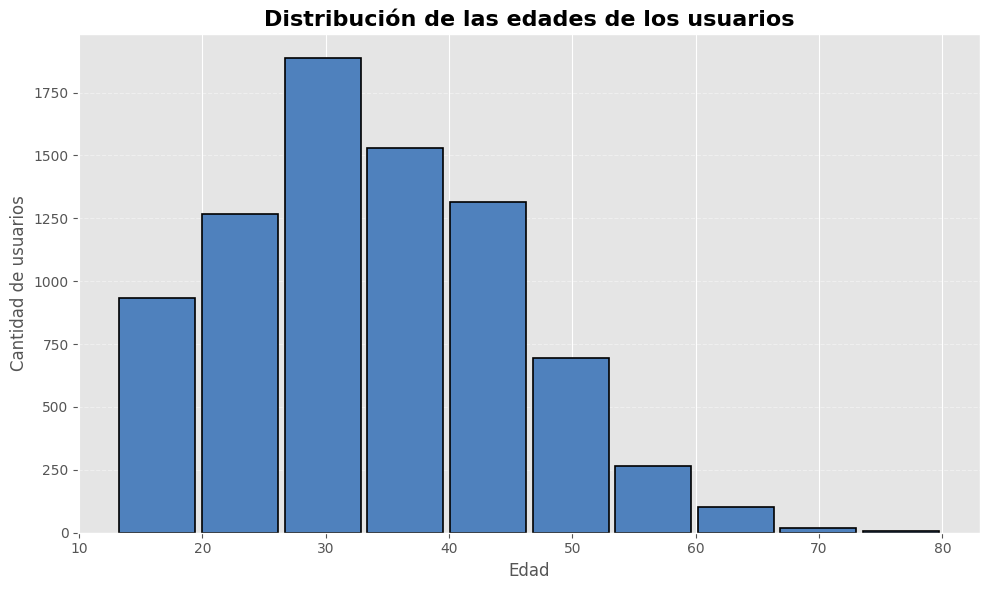

In [25]:
plt.figure(figsize=(10,6))

plt.hist(
    df["age"],
    bins=10,
    color="#4F81BD",
    edgecolor="black",
    linewidth=1.2,
    rwidth=0.92
)

plt.title(
    "Distribución de las edades de los usuarios",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Edad", fontsize=12)
plt.ylabel("Cantidad de usuarios", fontsize=12)

plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()

plt.show()

El gráfico muestra la cantidad de usuarios que posee cada plan de suscripción. Esta visualización permite identificar cuál es el plan más elegido por los usuarios y comparar la diferencia de cantidad entre cada uno de ellos. Esta información ayuda a comprender cómo se distribuyen los clientes dentro de la plataforma.

Paso 6 - Análisis univariado: Distribución de los planes de suscripción

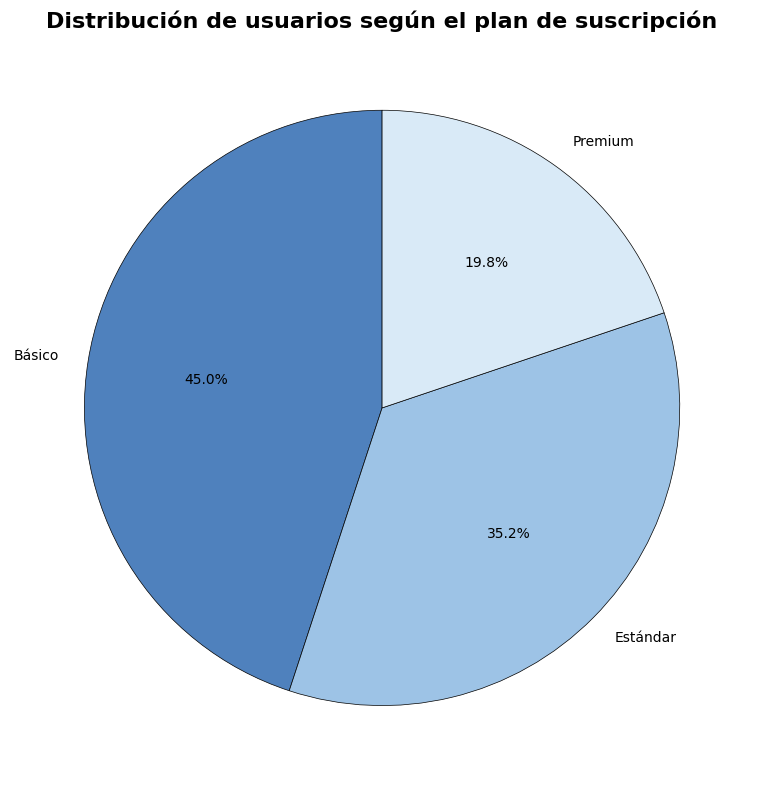

In [27]:
planes = df["subscription_plan"].value_counts()

plt.figure(figsize=(8,8))

plt.pie(
    planes,
    labels=planes.index,
    autopct="%1.1f%%",
    startangle=90,
    colors=["#4F81BD","#9DC3E6","#D9EAF7"],
    wedgeprops={"edgecolor":"black"}
)

plt.title(
    "Distribución de usuarios según el plan de suscripción",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()

plt.show()

El gráfico muestra la cantidad de usuarios que posee cada plan de suscripción. Se observa que el plan **Básico** es el más utilizado, seguido por **Estándar**, mientras que **Premium** presenta la menor cantidad de usuarios. Esto indica que la mayoría de los clientes prefiere opciones de menor costo, lo que puede estar relacionado con sus necesidades o posibilidades económicas.

Paso 7 - Análisis bivariado: Tiempo de visualización según el plan de suscripción

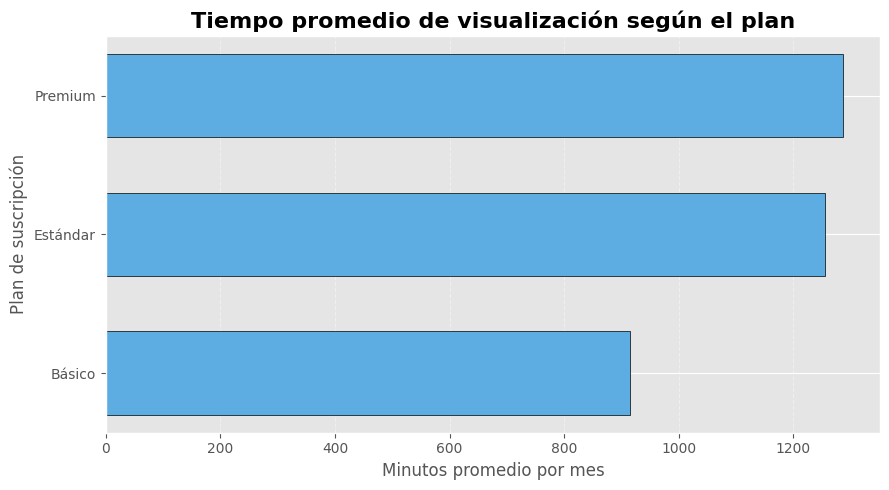

In [32]:
# Calcular el promedio de minutos por plan
watch_time = df.groupby("subscription_plan")["monthly_watch_time_mins"].mean()

# Ordenar de menor a mayor
watch_time = watch_time.sort_values()

# Crear el gráfico
plt.figure(figsize=(9,5))

plt.barh(
    watch_time.index,
    watch_time.values,
    color="#5DADE2",
    edgecolor="black",
    height=0.6
)

plt.title(
    "Tiempo promedio de visualización según el plan",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Minutos promedio por mes", fontsize=12)
plt.ylabel("Plan de suscripción", fontsize=12)

plt.grid(axis="x", linestyle="--", alpha=0.4)

plt.tight_layout()

plt.show()

El gráfico compara el tiempo promedio de visualización mensual entre los distintos planes de suscripción. Este análisis permite identificar si los usuarios de un determinado plan utilizan con mayor frecuencia la plataforma y si existe una relación entre el tipo de suscripción y el tiempo de uso.

Paso 8 - Análisis bivariado: Tiempo promedio de visualización por país

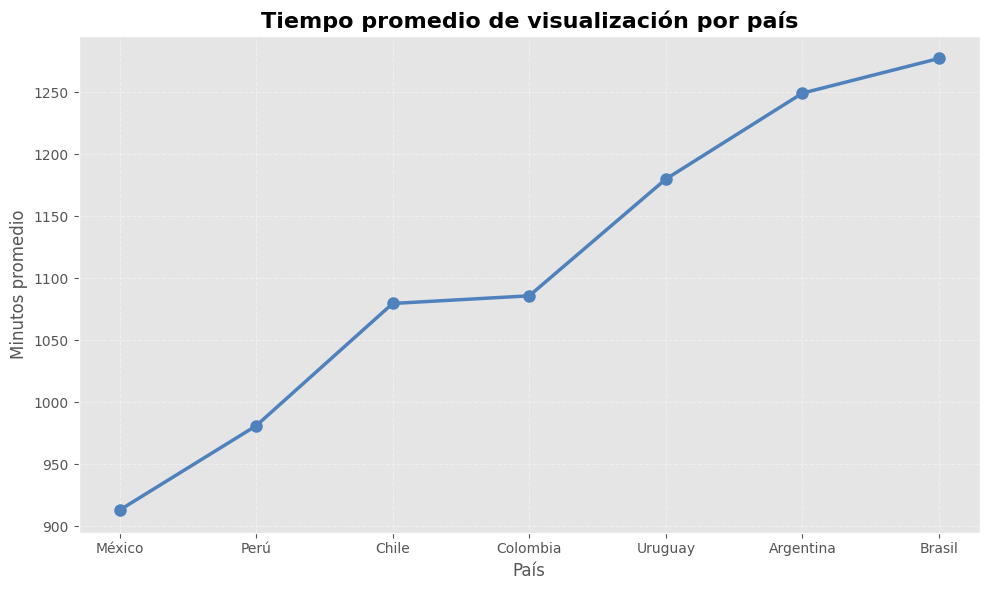

In [30]:
pais = df.groupby("country")["monthly_watch_time_mins"].mean()

pais = pais.sort_values()

plt.figure(figsize=(10,6))

plt.plot(
    pais.index,
    pais.values,
    marker="o",
    linewidth=2.5,
    markersize=8,
    color="#4F81BD"
)

plt.title(
    "Tiempo promedio de visualización por país",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("País")
plt.ylabel("Minutos promedio")

plt.grid(True, linestyle="--", alpha=0.4)

plt.tight_layout()

plt.show()

El gráfico permite comparar el tiempo promedio de visualización mensual entre los diferentes países. A partir de esta información es posible identificar qué países registran un mayor nivel de uso de la plataforma y observar si existen diferencias significativas en los hábitos de visualización de los usuarios.

Paso 9 - Análisis multivariado: Matriz de correlación

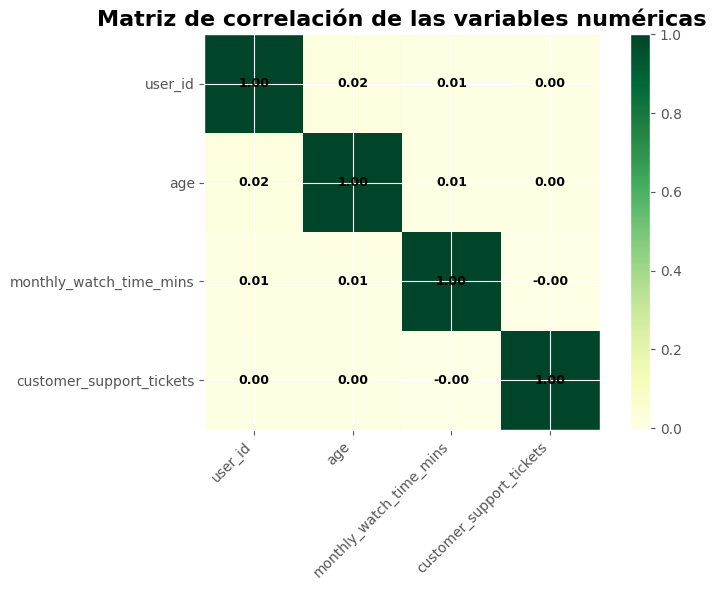

In [33]:
correlacion = df.select_dtypes(include=["int64", "float64"]).corr()

plt.figure(figsize=(8,6))

plt.imshow(
    correlacion,
    cmap="YlGn"
)

plt.colorbar()

plt.xticks(
    range(len(correlacion.columns)),
    correlacion.columns,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(correlacion.columns)),
    correlacion.columns
)

for i in range(len(correlacion.columns)):
    for j in range(len(correlacion.columns)):
        plt.text(
            j,
            i,
            f"{correlacion.iloc[i, j]:.2f}",
            ha="center",
            va="center",
            fontsize=9,
            fontweight="bold",
            color="black"
        )

plt.title(
    "Matriz de correlación de las variables numéricas",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()

plt.show()

La matriz de correlación muestra el grado de relación entre las variables numéricas del dataset. Los valores cercanos a 1 indican una relación positiva fuerte, los cercanos a -1 una relación negativa fuerte y los valores próximos a 0 indican que prácticamente no existe relación lineal entre las variables analizadas. Este análisis ayuda a identificar posibles asociaciones que pueden ser útiles para interpretar el comportamiento de los usuarios.

Durante el análisis exploratorio fue posible conocer mejor las características del conjunto de datos mediante distintas visualizaciones. Se observó cómo se distribuyen las edades de los usuarios, cuál es el plan de suscripción más utilizado y cómo varía el tiempo de visualización según el plan y el país. Además, la matriz de correlación permitió identificar la relación entre las variables numéricas.

En general, el análisis permitió responder las preguntas planteadas al inicio del proyecto y brindó una visión más clara del comportamiento de los usuarios. Esta información servirá como base para la siguiente etapa, donde se aplicará la técnica de Análisis de Componentes Principales (PCA) para reducir la dimensionalidad y facilitar la interpretación de los datos.